In [1]:
import sys
from pathlib import Path
import torch
import numpy as np

# Setup Root e Import
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
from teacher_finetune_headtail import (
    TeacherModelConfig, 
    build_teacher_model, 
    build_teacher_tokenizer, 
    get_llrd_optimizer_parameters,
    WeightedBCETrainer,
    compute_metrics,
    calculate_pos_weight,
    bf16_supported
)
from transformers import DataCollatorWithPadding, TrainingArguments
from datasets import load_from_disk

# Paths
paths = get_paths(ROOT)
# Override: avevi detto che i dati sono in data/raw
DATA_DIR = paths.data_processed

print(f"Data Source: {DATA_DIR}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data Source: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\data\processed
Device: NVIDIA GeForce RTX 3070


In [2]:
# Caricamento Dataset (Tokenized Head+Tail)
# Assicurati che i nomi corrispondano a come li hai salvati (train.parquet o train.hf cartella)
# Se hai salvato come parquet singoli, usa load_dataset("parquet", data_files=...)
# Se hai salvato con save_to_disk (cartelle), usa load_from_disk

try:
    # Caso 1: Cartelle HF (se salvate con save_to_disk)
    train_ds = load_from_disk(str(DATA_DIR / "train.hf"))
    val_ds = load_from_disk(str(DATA_DIR / "val.hf"))
except:
    # Caso 2: File Parquet (se salvati con to_parquet)
    from datasets import load_dataset
    print("Loading from Parquet files...")
    train_ds = load_dataset("parquet", data_files=str(DATA_DIR / "train.parquet"))["train"]
    val_ds = load_dataset("parquet", data_files=str(DATA_DIR / "val.parquet"))["train"]

print(f"Train size: {len(train_ds)}")
print(f"Val size:   {len(val_ds)}")

Loading from Parquet files...
Train size: 231423
Val size:   34912


In [3]:
# Calcolo automatico del peso per la Loss
# Se il dataset è bilanciato (50/50), questo valore sarà 1.0
# Se è sbilanciato (originale), sarà circa 2.8 - 3.0
pos_weight = calculate_pos_weight(train_ds)

print(f"--- Class Weight Configuration ---")
print(f"Calculated Positive Class Weight: {pos_weight:.4f}")

if 0.9 < pos_weight < 1.1:
    print(">> Dataset appears Balanced. Standard training applies.")
else:
    print(">> Dataset appears Imbalanced. Weighted Loss will be used.")

--- Class Weight Configuration ---
Calculated Positive Class Weight: 2.8518
>> Dataset appears Imbalanced. Weighted Loss will be used.


In [4]:
MODEL_NAME = "bert-base-uncased"

# 1. Tokenizer & Model
tokenizer = build_teacher_tokenizer(MODEL_NAME)
config = TeacherModelConfig(
    model_name=MODEL_NAME,
    gradient_checkpointing=True # Risparmia VRAM
)
model = build_teacher_model(config)

# 2. Optimizer LLRD (Layer-wise Decay)
LR = 2e-5
WEIGHT_DECAY = 0.01
optimizer_grouped_parameters = get_llrd_optimizer_parameters(
    model, learning_rate=LR, weight_decay=WEIGHT_DECAY, layer_decay=0.95
)
# Creiamo l'optimizer manualmente per passarlo al Trainer
optimizer = torch.optim.AdamW(optimizer_grouped_parameters)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# Parametri Hardware
BATCH_SIZE = 4        # Fisico (non esplodere VRAM)
ACCUMULATION = 4      # Accumulo (Batch effettivo = 16)
EPOCHS = 3

training_args = TrainingArguments(
    output_dir=str(paths.checkpoints / "bert_teacher_finetuned"),
    
    # Batch & Epochs
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2, # Eval consuma meno RAM
    gradient_accumulation_steps=ACCUMULATION,
    num_train_epochs=EPOCHS,
    
    # Optimization
    fp16=True, # RTX 3070 supporta bene FP16
    #weight_decay=0.01,
    # Logging & Save
    logging_steps=100,
    eval_strategy="steps", # Valuta a fine epoca
    eval_steps=1000,
    save_strategy="steps", # Salva a fine epoca
    save_steps=1000,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="pr_auc", # Massimizziamo F1 su classe Spoiler
    greater_is_better=True,
    report_to="none",
    warmup_ratio=0.06,
    # Cleanup
    dataloader_num_workers=0,
    group_by_length=True # Velocizza il training raggruppando lunghezze simili
)

collator = DataCollatorWithPadding(tokenizer)

In [6]:
from transformers import get_linear_schedule_with_warmup

num_training_steps = (len(train_ds) // (BATCH_SIZE * ACCUMULATION)) * EPOCHS
num_warmup_steps = int(0.06 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)


# Inizializzazione Trainer Custom
trainer = WeightedBCETrainer(
    pos_weight=pos_weight, # Passiamo il peso calcolato
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, scheduler) # Passiamo il nostro optimizer custom
)

print("Starting Training...")
trainer.train()

C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\src\teacher_finetune_headtail.py:122: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedBCETrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Trainer initialized with Weighted Loss. Pos Weight: 2.8518
Starting Training...


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc,Pr Auc
1000,0.898800,0.896373,0.638319,0.519795,0.396611,0.753972,0.747938,0.517045
2000,0.887200,0.826674,0.694919,0.559384,0.447482,0.745918,0.787562,0.591420
3000,0.867900,0.837908,0.669827,0.554856,0.426831,0.792586,0.790526,0.587329
4000,0.837400,0.861997,0.767959,0.567924,0.549716,0.587379,0.785102,0.601384
5000,0.824500,0.819921,0.743068,0.580410,0.503817,0.684466,0.798830,0.618606
6000,0.794800,0.837118,0.686154,0.562787,0.440833,0.778023,0.800486,0.619886
7000,0.791100,1.031652,0.791705,0.425865,0.748751,0.297551,0.796182,0.610568
8000,0.834700,0.815483,0.772714,0.587471,0.555501,0.623345,0.804740,0.628310
9000,0.795600,0.836843,0.771425,0.581234,0.554243,0.610989,0.799614,0.615144
10000,0.795900,0.810471,0.767816,0.592089,0.544319,0.649051,0.806947,0.617690


TrainOutput(global_step=43392, training_loss=0.7322223979463268, metrics={'train_runtime': 15786.6527, 'train_samples_per_second': 43.978, 'train_steps_per_second': 2.749, 'total_flos': 1.0166801146014923e+17, 'train_loss': 0.7322223979463268, 'epoch': 3.0})

In [ ]:
import json
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 1) predizione sulla validation
pred_out = trainer.predict(val_ds)   # o trainer.predict(val_dataset) a seconda dei tuoi nomi
logits = pred_out.predictions.reshape(-1)         # perché hai 1 logit per esempio :contentReference[oaicite:1]{index=1}
labels = pred_out.label_ids.astype(int)

probs = sigmoid(logits)

# 2) grid search semplice sulle soglie
thresholds = np.linspace(0.01, 0.99, 99)
best = {"threshold": 0.5, "f1": -1, "precision": None, "recall": None}

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(labels, preds, pos_label=1)
    if f1 > best["f1"]:
        best["threshold"] = float(t)
        best["f1"] = float(f1)
        best["precision"] = float(precision_score(labels, preds, pos_label=1, zero_division=0))
        best["recall"] = float(recall_score(labels, preds, pos_label=1, zero_division=0))

print("Best threshold on validation:", best)



Best threshold on validation: {'threshold': 0.5800000000000001, 'f1': 0.6046793061718435, 'precision': 0.5568350668647846, 'recall': 0.6615180935569285}


NameError: name 'os' is not defined

In [10]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

t = 0.58  # la soglia trovata su validation

test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

test_out = trainer.predict(test_ds)
logits = test_out.predictions.reshape(-1)
y_true = test_out.label_ids.astype(int)
probs = sigmoid(logits)
y_pred = (probs >= t).astype(int)

print("TEST F1:", f1_score(y_true, y_pred, pos_label=1))
print("TEST Precision:", precision_score(y_true, y_pred, pos_label=1, zero_division=0))
print("TEST Recall:", recall_score(y_true, y_pred, pos_label=1, zero_division=0))
print("TEST ROC-AUC:", roc_auc_score(y_true, probs))
print("TEST PR-AUC:", average_precision_score(y_true, probs))


Generating train split: 31344 examples [00:00, 141243.72 examples/s]


TEST F1: 0.5953599454111225
TEST Precision: 0.5540268811514446
TEST Recall: 0.6433575027651468
TEST ROC-AUC: 0.817178489861107
TEST PR-AUC: 0.6544173669782125


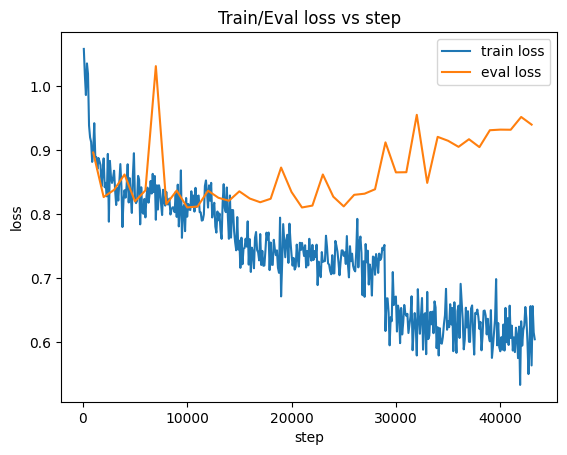

In [12]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

for row in log_history:
    if "loss" in row and "eval_loss" not in row:   # training log
        train_steps.append(row.get("step", None))
        train_loss.append(row["loss"])
    if "eval_loss" in row:                         # evaluation log
        eval_steps.append(row.get("step", None))
        eval_loss.append(row["eval_loss"])

plt.figure()
plt.plot(train_steps, train_loss, label="train loss")
plt.plot(eval_steps, eval_loss, label="eval loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Train/Eval loss vs step")
plt.legend()
plt.show()


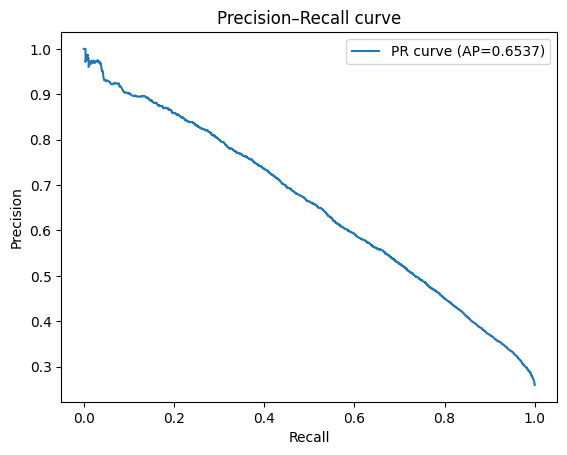

In [13]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# scegli dataset: val_ds o test_ds
pred_out = trainer.predict(val_ds)

logits = pred_out.predictions.reshape(-1)
labels = pred_out.label_ids.astype(int)
probs  = sigmoid(logits)


from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(labels, probs, pos_label=1)
pr_auc = average_precision_score(labels, probs)

plt.figure()
plt.plot(recall, precision, label=f"PR curve (AP={pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.show()


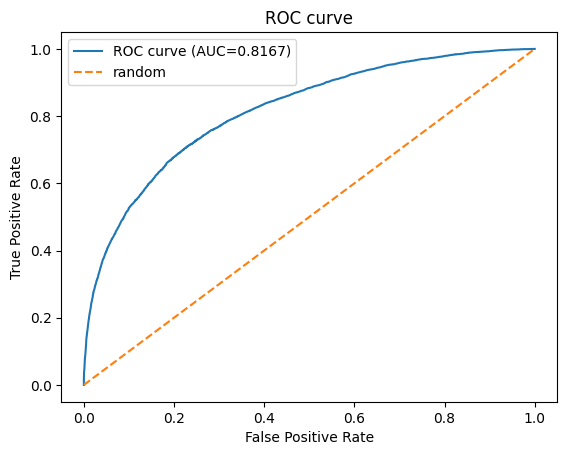

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(labels, probs, pos_label=1)
roc_auc = roc_auc_score(labels, probs)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()


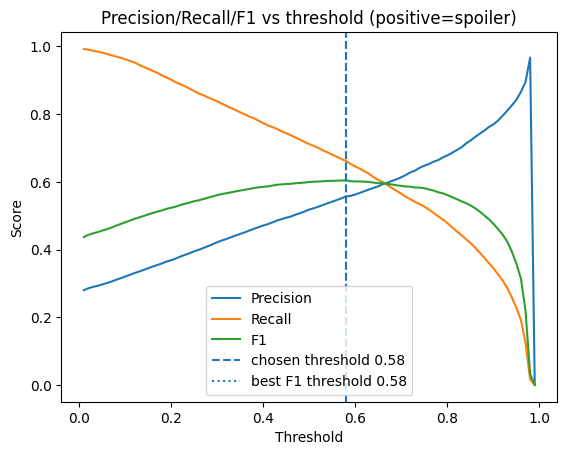

Best threshold by scan: 0.5800000000000001 Best F1: 0.6046793061718435


In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.01, 0.99, 99)
P, R, F = [], [], []

for t in thresholds:
    pred = (probs >= t).astype(int)
    P.append(precision_score(labels, pred, pos_label=1, zero_division=0))
    R.append(recall_score(labels, pred, pos_label=1, zero_division=0))
    F.append(f1_score(labels, pred, pos_label=1))

best_t = thresholds[int(np.argmax(F))]

plt.figure()
plt.plot(thresholds, P, label="Precision")
plt.plot(thresholds, R, label="Recall")
plt.plot(thresholds, F, label="F1")
plt.axvline(0.58, linestyle="--", label="chosen threshold 0.58")
plt.axvline(best_t, linestyle=":", label=f"best F1 threshold {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall/F1 vs threshold (positive=spoiler)")
plt.legend()
plt.show()

print("Best threshold by scan:", best_t, "Best F1:", max(F))
